In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from joblib import Parallel, delayed
from scipy.interpolate import make_smoothing_spline

# Get metabolomics data

In [2]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'


In [3]:
normalization = 'TIC'#
fn1 = metabolomics_folder / f'D_batch_1_4_{normalization}_norm.csv'
df1 = pd.read_csv(fn1, index_col=0)
df1.rename(columns={'metabolite':'Metabolite'}, inplace = True)

In [4]:
df1m = df1.loc[df1.Metabolite == 'Methionine']

# Parse metadata

In [5]:
samples_fn = metabolomics_folder / 'A_samples.csv'
samples_df = pd.read_csv(samples_fn, index_col=0)

# Parse header
And make long dataframe with metadata

## Batch 1-4

In [6]:
df1m

,ionMz,Metabolite,KEGG,00001 / NaN | STD | STD | NaN | yes | STD,00002 / NaN | STD | STD | NaN | yes | STD,00003 / NaN | STD | STD | NaN | yes | STD,00004 / NaN | STD | STD | NaN | yes | STD,00005 / NaN | STD | STD | NaN | yes | STD,00006 / NaN | STD | STD | NaN | yes | STD,00007 / NaN | STD | STD | NaN | yes | STD,...,10424 / 4 | A | dppB | 07 | yes | P19,10426 / 5 | C | kgtP | 08 | yes | P28,10427 / 5 | C | livH | 09 | yes | P29,10428 / 5 | C | livH | 09 | yes | P29,10430 / 5 | B | metI | 09 | yes | P29,10431 / 5 | B | rhtB | 09 | yes | P29,10432 / 5 | B | livH | 09 | yes | P29,10434 / 5 | A | livH | 09 | yes | P29,10436 / 5 | C | yahN | 09 | yes | P29,10438 / 5 | C | hisQ | 10 | yes | P30
142,148.044,Methionine,C00073; C00855; C01733; C07418,48864,48332,55002,58934,55006,62058,66423,...,11204,11207,12381,12182,11435,9833,11980,13638,9609,15317


In [7]:
# Optional parsing [x.replace(' ','').split('|') for x in df_norm.columns[3:]]
metadata1 = pd.DataFrame([[y.strip(' ') for y in x.split('|')] for x in df1m.columns[3:]], columns = ['#/Batch', 'Replicate', 'Strain', 'Timepoint', 'Norm', 'Plate'])



In [8]:
metadata1[['#','Batch']] = metadata1['#/Batch'].str.split(' / ',n=1, expand=True)

In [9]:
metadata1.Timepoint = [f'T{int(x)}' if x!='NaN' else x for x in metadata1.Timepoint]

In [10]:
column_names = metadata1['#/Batch']
df1m.columns = list(df1m.columns[:3]) + list(column_names)

In [11]:
df1L = df1m.melt(id_vars=['Metabolite', 'ionMz', 'KEGG'], var_name='Sample ID', value_name='Peak Intensity')



<Axes: xlabel='Timepoint', ylabel='Peak Intensity'>

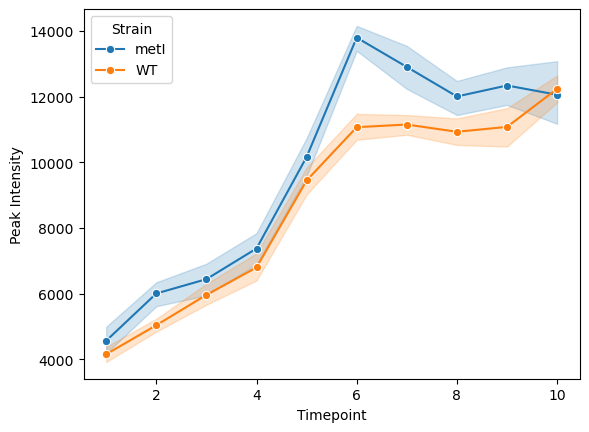

In [69]:
sns.lineplot(data=df1L.loc[(df1L.Strain.isin(['metI', 'WT']))&(df1L.Metabolite=='Methionine')], x='Timepoint', y='Peak Intensity', marker='o', hue = 'Strain')

# Add metadata

In [14]:
df1L = df1L.merge(metadata1, left_on='Sample ID', right_on='#/Batch', how='left')



In [15]:
df1L['#'] = df1L['#'].astype(int)

In [17]:
df1L.replace({'Timepoint': {'NaN': np.nan}}, inplace=True)
df1L.dropna(subset=['Timepoint'], inplace=True)

In [18]:
df1L = df1L.loc[~((df1L.Batch.astype(int)<5)&(df1L['#'] > 8000))]


<Axes: xlabel='#', ylabel='Peak Intensity'>

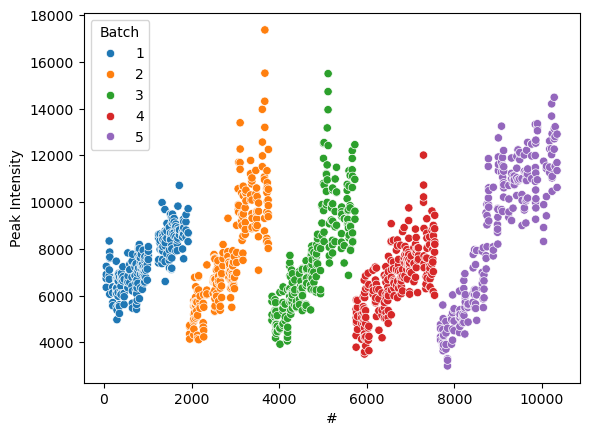

In [21]:
sns.scatterplot(data=df1L.loc[df1L.Strain=='WT'], x='#', y='Peak Intensity', hue='Batch', marker='o')

In [22]:
mean = df1L['Peak Intensity'].mean()
std = df1L['Peak Intensity'].std()
df1L['Z-score'] = (df1L['Peak Intensity']-mean)/std

# Get OD data

In [23]:
od_fn = metabolomics_folder / 'F_od_and_auc.csv'
od_df = pd.read_csv(od_fn, index_col=0)

In [24]:
strains = sorted([x for x in od_df['Strain'].unique()])

# Merge OD and metabolomics

### Fix columns before merge

In [25]:
od_df.replace({'Timepoint':'nan'}, np.nan, inplace=True)
od_df['Timepoint'] = [float(x.strip('T')) if isinstance(x, str) else x for x in od_df.Timepoint]


In [29]:
df1L['Timepoint'] = [float(x.strip('T')) if isinstance(x, str) else x for x in df1L.Timepoint]

In [32]:
df1L.Batch = df1L.Batch.astype(int)

In [33]:
df_full = pd.merge(left = df1L, right = od_df, left_on=('Strain','Replicate','Timepoint', 'Batch'), right_on=('Strain', 'Parallel', 'Timepoint', 'Batch'), how='left')



In [37]:
df_average = df_full.groupby(['Batch-Tube', 'Timepoint', 'ionMz','Metabolite', 'KEGG', 'Medium']).agg({'Z-score':('mean','std','median'),'OD':'first', 'AUC OD':'first', 'Hours':'first', 'Strain':'first', 
                                                                    'Parallel':'first', 'Batch':'first', 
                                                                    '#':'first', 'Exp. phase time limit':'first', 'Tube':'first'}).reset_index()


In [40]:
df_average.columns = ['Batch-Tube', 'Timepoint', 'ionMz','Metabolite', 'KEGG', 'Medium', 'Z-score mean', 'Z-score std', 'Z-score median', 'OD', 'AUC OD', 'Hours', 'Strain','Parallel', 'Batch', '#', 'Exp. phase time limit', 'Tube']

# Estimate effect

## Define functions

In [41]:
def spline_distance_and_std2(data, g1, g2, group = 'Strain', xval = 'AUC OD', 
                            yval = 'Median Z-score', 
                            ystd = 'Z-score std',
                            lam = 10, n_x_grid = 100, uniform_grid = False,
                            permutations = False):
    """
    Calculate the distance between two splines fitted to the data for two groups.
    Args:
        data (pd.DataFrame): DataFrame containing the data.
        g1 (str): First group to compare.
        g2 (str): Second group to compare (WT).
        group (str): Column name for grouping.
        xval (str): Column name for x-axis values.
        yval (str): Column name for y-axis values.
        ystd (str): Column name for standard deviation of y-axis values.
        lam (float): Smoothing parameter for spline fitting (10-100 works well).
        n_x_grid (int): Number of points in the x grid for interpolation.
    Returns:
        rel_distance (float): Relative distance between the two splines.
        mean_diff (float): Mean difference between the two splines.
        mae1 (float): Mean absolute error for the first group.
        mae2 (float): Mean absolute error for the second group.
        mean_mae (float): Mean absolute error averaged over both groups.
    """

    dg1 = data.loc[data[group] == g1]
    dg2 = data.loc[data[group] == g2]
    
    x1 = dg1[xval].values
    y1 = dg1[yval].values
    y1std = dg1[ystd].values 

    x2 = dg2[xval].values
    y2 = dg2[yval].values
    y2std = dg2[ystd].values

    if uniform_grid:
        # Define common x grid (e.g., union or intersection)
        x_common = np.linspace(max(x1.min(), x2.min()), min(x1.max(), x2.max()), n_x_grid, endpoint=True)
    else:
        x_min = max(x1.min(), x2.min())
        x_max = min(x1.max(), x2.max())
        x_common = np.sort([x for x in np.concatenate((x1, x2)) if x_min <= x <= x_max])

    # Spline interpolation
    w1 = 1/y1std
    w2 = 1/y2std

    spline1  =  make_smoothing_spline(x1, y1, w = w1, lam =lam)
    spline2  =  make_smoothing_spline(x2, y2, w = w2, lam =lam)


    # Estimate distance
    spline_distance = spline1(x_common)-spline2(x_common)
    # Absolute mean distance
    mean_abs_diff = np.mean(np.abs(spline_distance))
    # Mean distance
    mean_diff = np.mean(spline_distance)

    # Mean absolute error
    mae1 = np.mean(np.abs(spline1(x1) - y1))
    mae2 = np.mean(np.abs(spline2(x2) - y2))
    mean_mae = (mae1 + mae2) / 2.0

    # Relative distance
    rel_abs_distance = mean_abs_diff / mean_mae
    rel_distance = mean_diff / mean_mae
    

    if permutations:
        return rel_abs_distance, rel_distance
    else:
        return rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae



In [42]:
def perform_permutations2(n_perms, data, g1, g2, 
                        xval, yval, lam = 10, bar = False):
    perm_stats_rel = []
    perm_stats_abs = []
    # Make sure there are no duplicated x-values at all
    is_duplicated = data[xval].duplicated()
    if np.any(is_duplicated):
        # Add tiny random noise to the x-values to break ties
        data.loc[is_duplicated, xval] += np.sort(np.random.normal(0, 1e-4, size=is_duplicated.sum()))

    data.sort_values(by = xval, inplace = True, ascending= True)


    loop = tqdm(range(n_perms)) if bar else range(n_perms)
    
    for _ in loop:
        data['Group'] = np.random.permutation(data['Strain'])
        rel_abs_dis, rel_dis = spline_distance_and_std2(data, g1 = g1, g2 = g2, group = 'Group', xval = xval,
                                        yval = yval, lam = lam, permutations = True)
        perm_stats_abs.append(rel_abs_dis)
        perm_stats_rel.append(rel_dis)
    
    return perm_stats_abs, perm_stats_rel
    
def process_strain_metabolite_2(strain, mz, dfmz, n_perms, xval = 'AUC OD', yval = 'Median Z-score',
                                lam = 10):
    data = dfmz.copy()
    # print(data['Strain'].unique())
    g1, g2 = sorted(data['Strain'].unique(), reverse=True)

    # Make sure there are no duplicated x-values for the same strain 
    is_duplicated = data[['Strain', xval]].duplicated()
    if np.any(is_duplicated):
        # Add tiny random noise to the x-values to break ties
        data.loc[is_duplicated, xval] += np.random.normal(0, 1e-4, size=is_duplicated.sum())
    data.sort_values(by = xval, inplace=True)

    rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae = spline_distance_and_std2(data,g1=g1, g2=g2, group = 'Strain', xval= xval,
                                                            yval=yval, lam = lam, permutations = False)
    
    if n_perms > 0:
        perm_stats_abs, perm_stats_rel = perform_permutations2(n_perms, data, g1, g2, 
                                          xval, yval, lam=lam)
        if rel_distance < 0:
            p_value_rel = np.sum(np.array(perm_stats_rel) <= rel_distance) / n_perms
        else:
            p_value_rel = np.sum(np.array(perm_stats_rel) >= rel_distance) / n_perms

        p_value_abs = np.sum(np.array(perm_stats_abs) >= rel_abs_distance) / n_perms
    else:
        p_value_rel = np.nan
        p_value_abs = np.nan
    return (strain, mz, rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs)

# Run screen

In [43]:
# Settings
xval = 'AUC OD'
yval = 'Median Z-score'
n_perms = 1000
n_jobs = 8
lam = 10
wt_strain = 'WT'


In [51]:
df = df_average.copy()

In [52]:
df.rename(columns={'Z-score median':'Median Z-score', 'Z-score std':'Z-score std'}, inplace=True)

In [55]:
dis_data = {}
run = True
if run:
    all_ions = df.ionMz.unique()
    all_strains = df.Strain.unique()
    jobs = []
    for i in range(len(all_strains)):
        strain = all_strains[i]
        if strain == 'WT':
            continue
        batch = df.loc[df.Strain==strain, 'Batch'].values[0]
        idxs = (df.Batch == batch)&(df.Strain.isin([strain, wt_strain]))
        dfs = df.loc[idxs]
        for mz in all_ions:
            if dis_data.get((strain, mz)):
                continue
            dfmz = dfs.loc[dfs.ionMz==mz]
            if len(dfmz) > 10:
                jobs.append((strain, mz, dfmz))

    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_strain_metabolite_2)(strain, mz, dfi, n_perms = n_perms, lam = lam, xval=xval, yval=yval)
        for strain, mz, dfi in jobs
    )

    # dis_data = {}
    for res in results:
        (strain, mz, rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs) = res
        dis_data[(strain, mz)] = [rel_abs_distance, rel_distance, mean_abs_diff, mean_diff, mae1, mae2, mean_mae, g1, g2, p_value_rel, p_value_abs]

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   12.0s
[Parallel(n_jobs=8)]: Done  67 out of  67 | elapsed:   19.7s finished


In [58]:
dis_df = pd.DataFrame(dis_data).T.reset_index()
dis_df.columns = ['Strain', 'ionMz', 'Rel. abs. distance', 'Rel. distance', 'Mean abs. distance', 'Mean distance',
                    'MAE1', 'MAE2', 'Mean MAE', 'Strain 1', 'Strain 2', 'p-value rel', 'p-value abs']

In [60]:
dis_df.sort_values(by='Rel. distance', ascending=False, inplace=True)

In [62]:
sel_df = dis_df.loc[(dis_df['p-value rel'] < 0.005)& (dis_df['Rel. distance'].abs() > 3)] 

In [64]:
dis_df.loc[dis_df['Strain']=='metI']

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs
61,metI,148.044,2.582331,2.564559,0.655724,0.651211,0.263,0.244854,0.253927,metI,WT,0.0,0.0


In [76]:
df_average = df_average.loc[df_average.Batch == 5]

In [82]:
df_average.loc[df_average.Strain.isin(['WT', 'metI'])].head(10)

,Batch-Tube,Timepoint,ionMz,Metabolite,KEGG,Medium,Z-score mean,Z-score std,Z-score median,OD,AUC OD,Hours,Strain,Parallel,Batch,#,Exp. phase time limit,Tube
1911,5-0A,1.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,-1.481840,0.113617,-1.471380,0.038,0.088706,4.0,WT,A,5,7750,12.0,0A
1912,5-0A,2.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,-1.081809,0.360314,-1.112335,0.344,0.655373,8.0,WT,A,5,7958,12.0,0A
1913,5-0A,3.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,-0.840489,0.452113,-0.879659,0.813,1.772039,10.0,WT,A,5,8238,12.0,0A
1914,5-0A,4.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,-0.252289,0.300757,-0.326788,1.039,2.742623,11.0,WT,A,5,8634,12.0,0A
1915,5-0A,5.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,0.676704,0.328032,0.725588,1.250,3.888373,12.0,WT,A,5,8742,12.0,0A
1916,5-0A,6.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,1.495871,0.432355,1.614450,1.372,5.212956,13.0,WT,A,5,9098,12.0,0A
1917,5-0A,7.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,1.333639,0.264568,1.426389,1.393,6.603873,14.0,WT,A,5,9338,12.0,0A
1918,5-0A,8.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,1.201398,0.413496,1.267358,1.382,7.988289,15.0,WT,A,5,9630,12.0,0A
1919,5-0A,9.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,1.460543,0.554900,1.352103,1.361,9.360623,16.0,WT,A,5,9857,12.0,0A
1920,5-0A,10.0,148.044,Methionine,C00073; C00855; C01733; C07418,M9 20 mM glucose pH 7.4,1.757684,0.406745,1.704745,1.259,14.609539,20.0,WT,A,5,10341,12.0,0A


<Axes: xlabel='Hours', ylabel='Z-score median'>

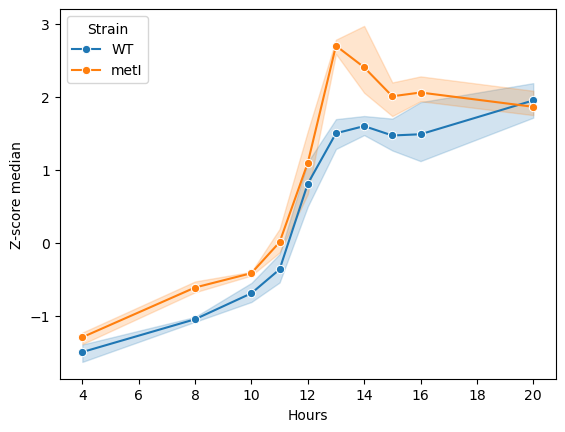

In [84]:
sns.lineplot(data=df_average.loc[df_average.Strain.isin(['WT', 'metI'])], x='Hours', y='Z-score median', hue='Strain', marker='o')